In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')

In [7]:
df = df.drop(columns=['Churn Reason'])

df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df = df.dropna()

df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('Churn Value', axis=1)

y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = joblib.load('../models/churn_model.pkl')

In [10]:
y_pred = model.predict(X_test)

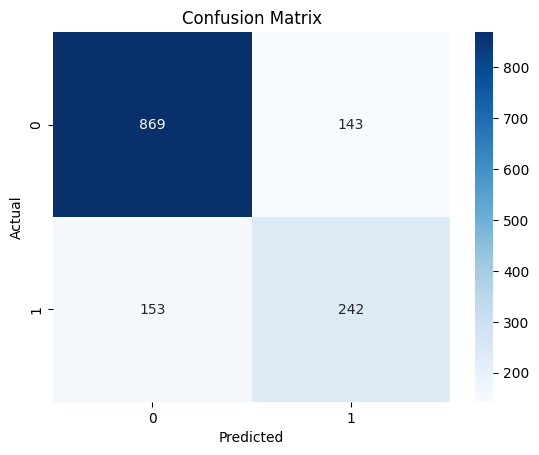

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [12]:
y_prob = model.predict_proba(X_test)[:, 1]

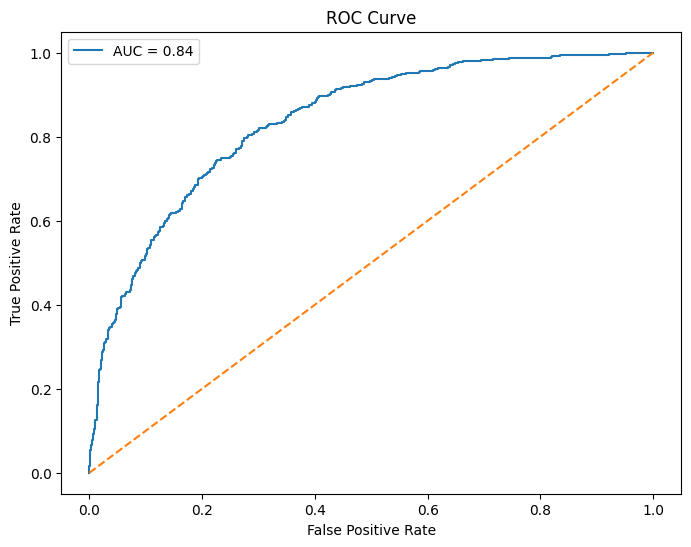

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()